# Diseño de sistema multiagente
## Coordinación descentralizada de una reunión entre amigos

Este notebook traduce a código el diseño descrito en el documento: un sistema **sin mediador**,
donde `n` agentes proxy (uno por amigo) negocian de forma **peer-to-peer** para acordar cuándo y
dónde reunirse. No hay agente coordinador central: la coordinación se logra con **reglas
deterministas y públicas** que cada agente evalúa localmente sobre una bitácora compartida.

Estructura del notebook (sigue las secciones del documento):

1. Agentes y entorno
2. Estado global `S` y observación pública `O_g` (bitácora replicada)
3. Acciones posibles
4. Objetivos individuales (`U_i`) y globales (`W`)
   - 4.1 Decisión bajo incertidumbre: MDP de un agente y ecuación de Bellman
   - 4.2 Observabilidad parcial: de MDP a Dec-POMDP
5. Restricciones y recursos compartidos
6. Mecanismo de coordinación (3 fases: CSP distribuido → votación → *two-phase commit*)
   - 6.1 Mecanismo alternativo: coordinación por subasta
   - 6.2 Ejercicio 4 — asignación óptima de recursos discretos (algoritmo húngaro)
7. Riesgos y mitigaciones
   - 7.1 Negociación estratégica y equilibrio de Nash
8. Formalización del agente (`A_i = (S_i, O_i, U_i, π_i, R_i)`)
   - 8.1 Arquitectura: pseudocódigo del ciclo individual y de la coordinación
   - 8.2 Introducción a Q-Learning: aprender π sin conocer el modelo
9. Simulación del sistema completo
   - 9.1 Mecanismos alternativos aplicados a la corrida real
10. Visualización de la corrida (animación reproducible + resultado final)


In [41]:
from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Dict, List, Tuple, Optional, Set
import random
import hashlib
import pandas as pd

random.seed(7)  # reproducibilidad de la simulación


## 1. Agentes y entorno

Todos los agentes son **pares**: mismo código, mismas atribuciones. Lo único que rota es el turno
de proponer, derivado de una regla determinista (no un rol asignado por nadie).

Además existen **agentes de entorno/servicio** (calendario, lugar, movilidad, clima) que no
negocian: solo informan. No se modelan aquí como agentes activos porque no toman decisiones ni
tienen utilidad propia; se representan simplemente como los datos que consultan los agentes
proxy (agenda, disponibilidad de local, coste de traslado).


In [42]:
def proponente(ronda: int, agentes_ordenados: List[str]) -> str:
    """proponente(ρ) = agentes[ρ mod n] sobre la lista ordenada de participantes.
    No es un rol asignado por nadie: cualquiera puede calcular a quién le toca sin preguntar."""
    return agentes_ordenados[ronda % len(agentes_ordenados)]


# Caracterización del entorno (tabla del documento, sección 1)
entorno = pd.DataFrame([
    ("Observabilidad", "Parcialmente observable", "Cada agente ignora las preferencias reales del resto → Dec-POMDP"),
    ("Determinismo",   "Estocástico",             "Cancelaciones, tráfico, local lleno"),
    ("Episodicidad",   "Secuencial",              "Lo que cedes hoy condiciona la próxima reunión"),
    ("Dinamismo",      "Dinámico",                "Las agendas cambian durante la negociación"),
    ("Discretización", "Tiempo discreto (slots), espacio continuo (ubicaciones)", "Slots como variables de un CSP"),
    ("Naturaleza",     "Cooperativo-mixto",       "Objetivo común (verse) + intereses divergentes (cuándo y dónde)"),
    ("Control",        "Descentralizado",         "Sin árbitro: la convergencia depende de reglas deterministas compartidas"),
], columns=["Dimensión", "Valor", "Implicación de diseño"])
entorno


,Dimensión,Valor,Implicación de diseño
0,Observabilidad,Parcialmente observable,Cada agente ignora las preferencias reales del...
1,Determinismo,Estocástico,"Cancelaciones, tráfico, local lleno"
2,Episodicidad,Secuencial,Lo que cedes hoy condiciona la próxima reunión
3,Dinamismo,Dinámico,Las agendas cambian durante la negociación
4,Discretización,"Tiempo discreto (slots), espacio continuo (ubi...",Slots como variables de un CSP
5,Naturaleza,Cooperativo-mixto,Objetivo común (verse) + intereses divergentes...
6,Control,Descentralizado,Sin árbitro: la convergencia depende de reglas...


## 2. Estado global `S` y observación pública `O_g`

`S` **nunca** es observable por completo por ningún agente:

```
S = ⟨ {A_i}, {P_i}, {L_i}, {B_i}, C, V, R, τ, θ ⟩
```

La parte pública (`C, V, R, τ, θ`) no vive en ningún nodo privilegiado: es una **bitácora de
solo-añadido** (`O_g`) que todos los agentes replican. Cada mensaje lleva emisor, número de
secuencia y ronda, y es **idempotente** (reenviarlo no altera el resultado). Aplicando los mismos
mensajes en el mismo orden total determinista, todos los agentes convergen al mismo `O_g`.

Lo que permanece **privado**: agenda literal (`A_i`), motivo de un rechazo, presupuesto (`B_i`) y
utilidad cardinal real (`P_i`).


In [43]:
Slot = int      # slot horario discreto
Ubicacion = str  # lugar (espacio continuo simplificado a un identificador)


@dataclass
class Candidata:
    """Una candidata (t, l) viva en C."""
    id: str
    t: Slot
    l: Ubicacion
    propuesta_por: str


@dataclass
class EstadoGlobal:
    """S = <{A_i}, {P_i}, {L_i}, {B_i}, C, V, R, τ, θ> — nunca observable por completo."""
    agendas: Dict[str, Set[Slot]] = field(default_factory=dict)              # A_i (privado)
    preferencias: Dict[str, Dict[str, float]] = field(default_factory=dict)  # P_i (privado)
    ubicaciones: Dict[str, Ubicacion] = field(default_factory=dict)          # L_i
    presupuestos: Dict[str, float] = field(default_factory=dict)             # B_i (privado)
    candidatas: Dict[str, Candidata] = field(default_factory=dict)           # C (público)
    votos: Dict[str, Dict[str, float]] = field(default_factory=dict)         # V (público)
    reservas: Dict[str, str] = field(default_factory=dict)                   # R (público)
    tau: int = 8                                                            # τ: tiempo restante
    theta: Dict[str, float] = field(default_factory=dict)                   # θ (público)


@dataclass
class Mensaje:
    emisor: str
    seq: int
    ronda: int
    tipo: str
    payload: dict


class Bitacora:
    """O_g: bitácora de solo-añadido, replicada por cada agente (ĝ_i).
    Idempotente (por emisor+seq) y con orden total determinista (ronda, emisor, seq)."""

    def __init__(self):
        self._mensajes: List[Mensaje] = []
        self._vistos: Set[Tuple[str, int]] = set()

    def append(self, msg: Mensaje) -> None:
        clave = (msg.emisor, msg.seq)
        if clave in self._vistos:
            return  # idempotencia: reenviar no altera el resultado
        self._vistos.add(clave)
        self._mensajes.append(msg)
        self._mensajes.sort(key=lambda m: (m.ronda, m.emisor, m.seq))

    def replicar_en(self, otra: "Bitacora") -> None:
        """Dados los mismos mensajes en el mismo orden, dos réplicas convergen al mismo estado."""
        for m in self._mensajes:
            otra.append(m)

    def de_tipo(self, tipo: str) -> List[Mensaje]:
        return [m for m in self._mensajes if m.tipo == tipo]

    def __len__(self) -> int:
        return len(self._mensajes)


## 3. Acciones posibles

Todos los agentes tienen el **mismo repertorio** (sección 3 y 8.3). Las funciones que en un
diseño centralizado ejecutaría un mediador (cerrar votación, adjudicar, desempatar) aquí **no son
acciones de nadie**: son reglas automáticas que se disparan solas (implementadas más abajo como
funciones puras sobre `O_g`, no como métodos de un agente especial).


In [44]:
class Accion(Enum):
    # Negociación
    PROPONER = auto()
    APROBAR = auto()
    RECHAZAR = auto()
    PUNTUAR = auto()
    CONTRAPROPONER = auto()
    CEDER = auto()
    VETAR = auto()
    # Información
    REVELAR = auto()
    DECLARAR_RESTRICCION = auto()
    # Compromiso
    PRE_COMPROMETER = auto()
    CONFIRMAR = auto()
    CANCELAR = auto()
    DELEGAR = auto()
    # Recurso externo
    RETENER_RECURSO = auto()
    LIBERAR_RECURSO = auto()
    # Nulas / control
    ESPERAR = auto()
    NUDGE = auto()


## 4. Objetivos individuales y globales

**Individual**: cada agente maximiza `U_i = E[Σ_t γᵗ · R_i(s_t, u_t)]`, con la recompensa `R_i`
de la sección 8.5 (incluye preferencia, costes, coste por ronda, coste de privacidad, valor de
quórum y crédito de equidad `θ_i`).

**Global**: sin mediador, `W` es una **fórmula pública** que cada agente computa sobre datos
públicos (nunca sobre las `U_i` reales, que son privadas). Se implementan las tres candidatas
del documento (utilitarista, igualitario, Nash) y el objetivo compuesto recomendado:

```
W(s) = λ·Σᵢ Uᵢ + (1−λ)·minᵢ(Uᵢ + θᵢ) − μ·ρ + ν·1[quórum ≥ k]
```


In [45]:
@dataclass
class Pesos:
    """Pesos personales de R_i (sección 8.5). Estimables por preferencia revelada."""
    w1: float = 1.0   # preferencia de tiempo
    w2: float = 1.0   # preferencia de lugar
    w3: float = 0.5   # coste de traslado
    w4: float = 0.5   # coste económico
    w5: float = 0.5   # conflicto de agenda
    w6: float = 0.1   # coste por ronda
    w7: float = 0.2   # coste de privacidad (información revelada)
    w8: float = 3.0   # valor de que ocurra la reunión (quórum alcanzado)
    w9: float = 0.3   # crédito de equidad (θ_i)
    w10: float = 5.0  # penalización por cancelar tras confirmar


def recompensa(pesos: Pesos, *, pref_t: float, pref_l: float, coste_traslado: float,
               coste_economico: float, conflicto: float, ronda: int, revelado: float,
               quorum_alcanzado: bool, theta_i: float, cancelo_tras_confirmar: bool) -> float:
    """R_i(s, u) — sección 8.5."""
    return (pesos.w1 * pref_t + pesos.w2 * pref_l
            - pesos.w3 * coste_traslado
            - pesos.w4 * coste_economico
            - pesos.w5 * conflicto
            - pesos.w6 * ronda
            - pesos.w7 * revelado
            + pesos.w8 * (1.0 if quorum_alcanzado else 0.0)
            + pesos.w9 * theta_i
            - pesos.w10 * (1.0 if cancelo_tras_confirmar else 0.0))


def bienestar_utilitarista(utilidades: Dict[str, float]) -> float:
    """W = Σ U_i — maximiza el total; sacrifica sistemáticamente al que vive lejos."""
    return sum(utilidades.values())


def bienestar_igualitario(utilidades: Dict[str, float]) -> float:
    """W = min_i U_i — protege al peor servido; puede bloquear opciones buenas para casi todos."""
    return min(utilidades.values())


def bienestar_nash(utilidades: Dict[str, float], desacuerdo: Dict[str, float]) -> float:
    """W = Π (U_i − d_i) — equilibrio; penaliza dejar a alguien en su punto de desacuerdo."""
    producto = 1.0
    for i, u in utilidades.items():
        producto *= max(u - desacuerdo.get(i, 0.0), 1e-9)
    return producto


def bienestar_compuesto(utilidades: Dict[str, float], theta: Dict[str, float], ronda: int,
                         quorum_ok: bool, lam: float = 0.6, mu: float = 0.2, nu: float = 2.0) -> float:
    """W(s) = λ·ΣUi + (1−λ)·min_i(Ui+θi) − μ·ρ + ν·1[quórum≥k] — calculable solo desde O_g,
    nunca desde las U_i reales (privadas): se evalúa sobre los votos declarados (públicos)."""
    total = sum(utilidades.values())
    peor_con_credito = min(utilidades[i] + theta.get(i, 0.0) for i in utilidades)
    return lam * total + (1 - lam) * peor_con_credito - mu * ronda + nu * (1.0 if quorum_ok else 0.0)


### 4.1 Decisión bajo incertidumbre: MDP de un agente y ecuación de Bellman

`U_i = E[Σ_t γᵗ · R_i(s_t, u_t)]` (arriba) ya asume una recompensa descontada, pero el notebook
nunca definió `γ` ni resolvió la decisión que hay detrás de esa suma: en cada ronda, ¿acepto la
mejor candidata disponible o espero a que salga una mejor? Es una decisión secuencial bajo
incertidumbre -- un problema de **parada óptima** -- que se puede plantear como un MDP de un
solo agente:

- **Estado** `s = t`: rondas restantes hasta el deadline `τ`.
- En cada estado se observa una utilidad `u_t` (la mejor candidata disponible esa ronda),
  muestreada de la distribución de preferencias cardinales `P_i` (sección 4).
- **Acciones**: `aceptar` (recompensa `u_t`, termina el episodio) o `esperar` (recompensa `-c`
  por ronda, pasa a `t+1`; al llegar a `τ` se fuerza el valor de reserva `r_i`).
- **Ecuación de Bellman** (horizonte finito, inducción hacia atrás):

```
V(τ) = r_i
V(t) = E_u[ max( u ,  -c + γ·V(t+1) ) ],   0 ≤ t < τ
```

El umbral óptimo en `t` es la utilidad mínima a partir de la cual conviene aceptar:
`u*(t) = -c + γ·V(t+1)`. Se resuelve por inducción hacia atrás; más abajo (sección 8, una vez
definido `AgenteProxy`) se compara con el umbral heurístico `φ_i(t)` que de verdad usa el
agente.

In [46]:
def valor_iteracion_umbral(niveles_utilidad: List[float], tau: int, gamma: float,
                            costo_espera: float, valor_reserva: float) -> Dict[int, float]:
    """Bellman por induccion hacia atras para el MDP de aceptar/esperar.
    Devuelve el umbral optimo u*(t) = -c + gamma*V(t+1) para cada ronda t."""
    v_siguiente = valor_reserva  # V(tau) = r_i
    umbrales: Dict[int, float] = {}
    for t in range(tau - 1, -1, -1):
        umbral = -costo_espera + gamma * v_siguiente
        umbrales[t] = umbral
        # V(t) = E_u[max(u, umbral)], u uniforme sobre niveles_utilidad
        v_siguiente = sum(max(u, umbral) for u in niveles_utilidad) / len(niveles_utilidad)
    return dict(sorted(umbrales.items()))


NIVELES_UTILIDAD = [0.0, 20.0, 40.0, 60.0, 80.0, 100.0]  # discretizacion de P_i (seccion 4)
TAU_EJEMPLO, GAMMA_EJEMPLO = 8, 0.9
COSTO_ESPERA_EJEMPLO, RESERVA_EJEMPLO = 2.0, 10.0

umbral_bellman = valor_iteracion_umbral(NIVELES_UTILIDAD, TAU_EJEMPLO, GAMMA_EJEMPLO,
                                         COSTO_ESPERA_EJEMPLO, RESERVA_EJEMPLO)

pd.DataFrame([
    {"t": t, "umbral_optimo_bellman (u*)": round(umbral_bellman[t], 2)}
    for t in range(TAU_EJEMPLO)
])

,t,umbral_optimo_bellman (u*)
0,0,62.00
1,1,61.67
2,2,61.12
3,3,60.20
4,4,58.22
5,5,53.82
6,6,44.05
7,7,7.00


### 4.2 Observabilidad parcial: de MDP a Dec-POMDP

El MDP anterior asume que el agente conoce con certeza su propio estado. Pero el problema real
(sección 1: "cada agente ignora las preferencias reales del resto") es multiagente y
**parcialmente observable** -- un Dec-POMDP:

```
⟨ I, S, {A_i}, T, {Ω_i}, O, {R_i}, γ ⟩
```

- `I`: agentes proxy (`NOMBRES`, sección 9).
- `S`: `EstadoGlobal` (sección 2) -- ningún agente lo observa completo.
- `{A_i}`: `Accion` (sección 3), una por agente.
- `T`: transición de estado que producen las fases 1→2→3 del mecanismo de coordinación
  (sección 6).
- `{Ω_i}`: observaciones privadas de `i` -- su propia agenda `A_i` y la bitácora pública `O_g`
  (idéntica para todos). Lo único no observado por nadie más es `P_i` (preferencia cardinal) y
  `B_i` (presupuesto).
- `O`: función de observación -- determinista y perfecta para lo que se anuncia en `O_g`, nula
  para `P_j`/`B_j` de los demás (`j ≠ i`).
- `{R_i}`: sección 4. `γ`: el mismo factor de descuento de 4.1.

Como cada agente no observa `P_j` de los demás, mantiene una **creencia** `β_i` sobre ellas
(`AgenteProxy.beta_i`, sección 8) y la actualiza con cada voto público observado
(`actualizar_creencias`, ya implementado). Esa función simplifica la actualización de creencias
a una media móvil; la forma general de un filtro de Bayes discreto es:

```
b'(h) ∝ P(o | h) · b(h)      (normalizando sobre todas las hipótesis h)
```

que se ilustra aquí sobre un ejemplo de juguete (independiente de la simulación) para contrastar
con la simplificación ya implementada.

In [47]:
def actualizar_creencia_bayesiana(prior: Dict[str, float],
                                   verosimilitud: Dict[str, Dict[str, float]],
                                   observacion: str) -> Dict[str, float]:
    """b'(h) ~ P(o|h)*b(h), normalizado -- version completa de la actualizacion de creencias
    que actualizar_creencias() simplifica a media movil (mas barata, sin modelo explicito de
    verosimilitud)."""
    sin_normalizar = {h: verosimilitud[h][observacion] * prior[h] for h in prior}
    total = sum(sin_normalizar.values())
    return {h: v / total for h, v in sin_normalizar.items()}


# Ejemplo de juguete: creencia sobre si un amigo prefiere "Cafeteria_A" mucho o poco
prior_ejemplo = {"prefiere_mucho": 0.5, "prefiere_poco": 0.5}
verosimilitud_ejemplo = {
    "prefiere_mucho": {"voto_alto": 0.8, "voto_bajo": 0.2},
    "prefiere_poco": {"voto_alto": 0.2, "voto_bajo": 0.8},
}

creencia = prior_ejemplo
secuencia_observada = ["voto_alto", "voto_alto", "voto_bajo"]
filas_creencia = [{"observacion": "prior", **creencia}]
for obs in secuencia_observada:
    creencia = actualizar_creencia_bayesiana(creencia, verosimilitud_ejemplo, obs)
    filas_creencia.append({"observacion": obs, **creencia})

pd.DataFrame(filas_creencia).round(3)

,observacion,prefiere_mucho,prefiere_poco
0,prior,0.500,0.500
1,voto_alto,0.800,0.200
2,voto_alto,0.941,0.059
3,voto_bajo,0.800,0.200


## 5. Restricciones y recursos compartidos

**Duras** (filtran el espacio de soluciones): solapamiento de agenda, capacidad/horario del
local, quórum mínimo `k`, deadline `τ = 0`, última salida de transporte, restricciones no
negociables. **Blandas**: entran en la utilidad, no eliminan candidatas.


In [48]:
def restriccion_dura_agenda(agenda: Set[Slot], t: Slot) -> bool:
    """True si el slot t NO choca con la agenda del agente (restricción dura de A_i)."""
    return t not in agenda


def restriccion_dura_transporte(t: Slot, ultima_salida: Slot) -> bool:
    """Ventana de transporte: el slot debe permitir volver antes de la última salida."""
    return t <= ultima_salida


def restriccion_dura_presupuesto(presupuesto: float, coste_local: float) -> bool:
    """Un local caro excluye de facto a quien tiene B_i bajo."""
    return coste_local <= presupuesto


recursos_compartidos = pd.DataFrame([
    ("Slot temporal común",       "Indivisible y excluyente",         "Recurso escaso: solo se puede elegir uno"),
    ("Mesa / reserva",            "Capacidad finita, competencia externa", "Race condition con grupos ajenos al sistema"),
    ("Presupuesto del grupo",     "Divisible, heterogéneo",           "Un local caro excluye a quien tiene B_i bajo"),
    ("Plazas de coche",           "Discreto, asignable",              "Subproblema de asignación anidado"),
    ("Paciencia / atención",      "Agotable y no renovable",          "Cada ronda consume un recurso que no vuelve"),
    ("Ancho de banda de mensajes","Crece con n²",                     "Sin mediador, cada mensaje va a todos: limita el tamaño del grupo"),
], columns=["Recurso", "Naturaleza", "Conflicto"])
recursos_compartidos


,Recurso,Naturaleza,Conflicto
0,Slot temporal común,Indivisible y excluyente,Recurso escaso: solo se puede elegir uno
1,Mesa / reserva,"Capacidad finita, competencia externa",Race condition con grupos ajenos al sistema
2,Presupuesto del grupo,"Divisible, heterogéneo",Un local caro excluye a quien tiene B_i bajo
3,Plazas de coche,"Discreto, asignable",Subproblema de asignación anidado
4,Paciencia / atención,Agotable y no renovable,Cada ronda consume un recurso que no vuelve
5,Ancho de banda de mensajes,Crece con n²,"Sin mediador, cada mensaje va a todos: limita ..."


## 6. Mecanismo de coordinación

Dos subproblemas distintos — **factibilidad** (CSP) y **elección** (agregación de preferencias)
— resueltos en tres fases, todas peer-to-peer.

### Fase 1 — Filtrado: CSP distribuido (ABT simplificado)
Cada agente emite solo `compatible`/`incompatible` sobre candidatas concretas, sin exponer su
agenda. Salida: `C_f`, idéntico en todas las réplicas. Si `C_f = ∅`, se relaja el quórum (de `n`
a `k`) de forma **explícita y visible**, nunca silenciosa.


In [49]:
def fase1_filtrado_csp(candidatas: List[Candidata], agentes: List["AgenteProxy"],
                        quorum_min: int) -> List[Candidata]:
    """Asynchronous Backtracking simplificado: cada agente solo dice compatible/incompatible,
    sin revelar su agenda real. C_f es idéntico en todas las réplicas porque se computa
    determinísticamente sobre datos que cada agente ya tiene."""

    def compatibles_con(c: Candidata) -> List["AgenteProxy"]:
        return [a for a in agentes if a.es_compatible(c)]

    factibles = [c for c in candidatas if len(compatibles_con(c)) >= quorum_min]

    if not factibles:
        k_relajado = max(2, quorum_min - 1)
        print(f"[fase1] C_f vacío con quórum={quorum_min} → relajación explícita a k={k_relajado}")
        factibles = [c for c in candidatas if len(compatibles_con(c)) >= k_relajado]

    return factibles


### Fase 2 — Elección: votación con presupuesto y cómputo replicado
Cada agente reparte 100 puntos entre candidatas (`puntuar(c, v)`) y difunde su vector por la
bitácora. La agregación es una función **determinista y pura** de los votos públicos: cualquier
agente que la evalúe sobre su réplica obtiene la misma ganadora. El empate se rompe con una regla
fija de antemano: mayor `θ_i` de quien propuso y, como último recurso, hash del identificador.


In [50]:
def fase2_votacion(agentes: List["AgenteProxy"], candidatas: List[Candidata],
                    bitacora: Bitacora, ronda: int) -> Tuple[Candidata, Dict[str, float]]:
    for i, a in enumerate(agentes):
        vector = a.puntuar_candidatas(candidatas)
        bitacora.append(Mensaje(a.nombre, i, ronda, "puntuar", {"votos": vector}))

    scores: Dict[str, float] = {c.id: 0.0 for c in candidatas}
    for m in bitacora.de_tipo("puntuar"):
        if m.ronda != ronda:
            continue
        for cid, v in m.payload["votos"].items():
            if cid in scores:
                scores[cid] += v

    ganadora_id = desempate(scores, agentes, candidatas)
    ganadora = next(c for c in candidatas if c.id == ganadora_id)
    return ganadora, scores


def desempate(scores: Dict[str, float], agentes: List["AgenteProxy"],
              candidatas: List[Candidata]) -> str:
    """Regla de desempate determinista, pública, anunciada de antemano: mayor θ_i de quien
    propuso y, como último recurso, hash del identificador de la candidata."""
    max_score = max(scores.values())
    empatadas = [cid for cid, s in scores.items() if s == max_score]
    if len(empatadas) == 1:
        return empatadas[0]

    theta_por_candidata = {}
    for c in candidatas:
        if c.id in empatadas:
            proponente_agente = next(a for a in agentes if a.nombre == c.propuesta_por)
            theta_por_candidata[c.id] = proponente_agente.theta_i
    max_theta = max(theta_por_candidata.values())
    empatadas2 = [cid for cid, t in theta_por_candidata.items() if t == max_theta]
    if len(empatadas2) == 1:
        return empatadas2[0]

    return min(empatadas2, key=lambda cid: hashlib.sha256(cid.encode()).hexdigest())


### Fase 3 — Compromiso: *two-phase commit* con coordinador transitorio
Quien propuso la candidata ganadora asume el rol de coordinador **solo para esa transacción**:
retiene el recurso externo con TTL, recoge los `pre_comprometer` y, al alcanzar el quórum,
difunde `confirmar`. Si cae o expira el TTL sin quórum, el siguiente agente del orden
determinista lo releva y se reintenta con la siguiente candidata (`C_f \ {c*}`).


In [51]:
def fase3_compromiso(ganadora: Candidata, agentes: List["AgenteProxy"], quorum_min: int,
                      ttl: int = 3) -> bool:
    coordinador = next(a for a in agentes if a.nombre == ganadora.propuesta_por)
    print(f"[fase3] {coordinador.nombre} coordinador transitorio de '{ganadora.id}' "
          f"(retiene recurso, TTL={ttl})")

    pre_comprometidos = [a.nombre for a in agentes if a.decide_comprometerse(ganadora)]

    if len(pre_comprometidos) >= quorum_min:
        for a in agentes:
            if a.nombre in pre_comprometidos:
                a.x_i = "confirmado"
        print(f"[fase3] quórum alcanzado ({len(pre_comprometidos)}/{quorum_min}) → "
              f"{coordinador.nombre} difunde confirmar()")
        return True

    print(f"[fase3] TTL expira sin quórum ({len(pre_comprometidos)}/{quorum_min}) → "
          f"se libera el recurso y releva el siguiente agente del orden determinista")
    return False


def coordinar_reunion(agentes: List["AgenteProxy"], candidatas_factibles: List[Candidata],
                       bitacora: Bitacora, ronda: int, quorum_min: int) -> Optional[Candidata]:
    """Orquesta fase 2 + fase 3, con reintento sobre las candidatas restantes (excluyendo
    la ganadora) si el compromiso falla (relevo del coordinador transitorio, sin bloquear
    al grupo)."""
    restantes = list(candidatas_factibles)
    while restantes:
        ganadora, scores = fase2_votacion(agentes, restantes, bitacora, ronda)
        if fase3_compromiso(ganadora, agentes, quorum_min):
            return ganadora
        restantes = [c for c in restantes if c.id != ganadora.id]
    return None


### 6.1 Mecanismo alternativo: coordinación por subasta

La fase 2 resuelve la elección con **votación por presupuesto de puntos** (100 puntos
ficticios por agente). Una alternativa igual de descentralizada -- sin mediador, con la misma
bitácora pública `O_g` como único canal -- es una **subasta de sobre cerrado a primer precio**:
cada agente puja con su propio presupuesto real (`B_i`, sección 2) en vez de puntos ficticios, y
gana la candidata que reúne la puja total más alta entre las factibles (`C_f`, fase 1).

A diferencia de la votación, donde repartir puntos en una candidata no cuesta nada fuera del
propio presupuesto de 100, aquí pujar alto compromete de verdad `B_i`: cambia los incentivos
frente a la manipulación (sección 7) porque exagerar una puja es costoso, no gratis. Se define
aquí como función pura sobre `O_g` (mismo patrón que `fase2_votacion`); se ejecuta más adelante
(sección 9.1) sobre la corrida real, junto a la votación.

In [52]:
def fase2_subasta(agentes: List["AgenteProxy"], candidatas: List[Candidata],
                   bitacora: Bitacora, ronda: int) -> Tuple[Candidata, Dict[str, float]]:
    """Subasta de sobre cerrado a primer precio: cada agente puja una parte de su presupuesto
    B_i real proporcional a su preferencia cardinal por cada candidata (misma logica de
    puntuar_candidatas, pero repartiendo B_i en vez de 100 puntos ficticios). Gana la candidata
    con la puja total mas alta; el desempate reutiliza la regla de fase 2 (desempate)."""
    for i, a in enumerate(agentes):
        pujas = a.puntuar_candidatas(candidatas, presupuesto_puntos=a.presupuesto)
        bitacora.append(Mensaje(a.nombre, i, ronda, "pujar", {"pujas": pujas}))

    total_pujado: Dict[str, float] = {c.id: 0.0 for c in candidatas}
    for m in bitacora.de_tipo("pujar"):
        if m.ronda != ronda:
            continue
        for cid, monto in m.payload["pujas"].items():
            if cid in total_pujado:
                total_pujado[cid] += monto

    ganadora_id = desempate(total_pujado, agentes, candidatas)
    ganadora = next(c for c in candidatas if c.id == ganadora_id)
    return ganadora, total_pujado

### 6.2 Ejercicio 4 — asignación óptima de recursos discretos (algoritmo húngaro)

La tabla de recursos compartidos (sección 5) señala las "Plazas de coche" como un
**subproblema de asignación anidado**: una vez fijada la reunión, hay que decidir quién va en
qué coche. A diferencia de elegir *una* candidata entre todas (fase 2), aquí cada persona debe
quedar asignada a **como mucho una** plaza y cada plaza a **como mucho una** persona -- un
problema de asignación biyectiva clásico, resoluble de forma óptima (no aproximada) con el
**algoritmo húngaro** (`scipy.optimize.linear_sum_assignment`), que minimiza el coste total en
tiempo polinómico (`O(n³)`) en vez de probar las combinaciones posibles.

**Ejercicio**: dado el coste de desvío (en minutos) de cada persona según la plaza a la que se
suba, encontrar la asignación persona→plaza que minimiza el desvío total del grupo.

In [53]:
from scipy.optimize import linear_sum_assignment

NOMBRES_EJERCICIO = ["Ana", "Beñat", "Carla", "Diego", "Elena"]
PLAZAS_POR_COCHE = {"Coche_Ana": 3, "Coche_Diego": 3}  # 2 coches, 6 plazas para 5 personas
plazas_ejercicio = [c for c, n in PLAZAS_POR_COCHE.items() for _ in range(n)]

rng_ejercicio = random.Random(11)  # RNG local: no altera la semilla global de la simulacion
coste_desvio = pd.DataFrame(
    [[round(rng_ejercicio.uniform(0, 25), 1) for _ in plazas_ejercicio] for _ in NOMBRES_EJERCICIO],
    index=NOMBRES_EJERCICIO, columns=plazas_ejercicio,
)
coste_desvio

,Coche_Ana,Coche_Ana,Coche_Ana,Coche_Diego,Coche_Diego,Coche_Diego
Ana,11.3,14.0,23.1,11.6,12.7,14.7
Beñat,4.6,12.8,15.7,19.8,2.4,7.6
Carla,2.3,20.2,17.3,1.0,24.6,24.1
Diego,16.3,15.4,3.9,0.4,13.2,1.5
Elena,4.8,6.0,0.8,11.6,11.0,21.1


In [54]:
filas_opt, columnas_opt = linear_sum_assignment(coste_desvio.values)

asignacion_optima = pd.DataFrame({
    "persona": [NOMBRES_EJERCICIO[i] for i in filas_opt],
    "plaza_asignada": [plazas_ejercicio[j] for j in columnas_opt],
    "coste_desvio_min": [round(coste_desvio.values[i, j], 1) for i, j in zip(filas_opt, columnas_opt)],
})

coste_optimo = coste_desvio.values[filas_opt, columnas_opt].sum()
coste_ingenuo = sum(coste_desvio.values[i, i] for i in range(len(NOMBRES_EJERCICIO)))
print(f"Coste total con el algoritmo hungaro (optimo):        {coste_optimo:.1f} min")
print(f"Coste total con una asignacion arbitraria (persona i -> plaza i): {coste_ingenuo:.1f} min")
asignacion_optima

Coste total con el algoritmo hungaro (optimo):        17.0 min
Coste total con una asignacion arbitraria (persona i -> plaza i): 52.8 min


,persona,plaza_asignada,coste_desvio_min
0,Ana,Coche_Ana,11.3
1,Beñat,Coche_Diego,2.4
2,Carla,Coche_Diego,1.0
3,Diego,Coche_Diego,1.5
4,Elena,Coche_Ana,0.8


## 7. Riesgos y mitigaciones

Se implementan dos de los riesgos más relevantes del documento: el **deadlock por espera mutua**
(mitigado con opción por defecto en `τ = 0`) y el **desempate determinista** (ya implementado en
`desempate`, cubre livelocks por contrapropuestas cíclicas y ciclos de Condorcet).


In [55]:
def resolver_por_defecto_si_deadlock(candidatas: List[Candidata], tau: int) -> Optional[Candidata]:
    """esperar() es la acción más peligrosa del sistema: si nadie propone y τ llega a 0,
    la opción por defecto se aplica sola, convirtiendo la inacción en una decisión
    (no en un bloqueo indefinido)."""
    if tau <= 0 and candidatas:
        print(f"[riesgo] τ=0 sin acuerdo → se aplica la opción por defecto: '{candidatas[0].id}'")
        return candidatas[0]
    return None


def penalizar_cancelacion(agente: "AgenteProxy") -> None:
    """cancelar(c) tras haberse confirmado es una deserción tardía, penalizada en θ
    (mitiga la 'tiranía del más flexible' junto con el término maximin de W)."""
    if agente.x_i == "confirmado":
        agente.x_i = "desertado"
        agente.theta_i -= 1.0


### 7.1 Negociación estratégica y equilibrio de Nash

Los riesgos anteriores (deadlock, manipulación) son, formalmente, juegos de 2 jugadores.
Formalizarlos como matrices de pago permite ver si la solución "cooperativa" es también un
**equilibrio de Nash** (nadie mejora desviándose unilateralmente) o si el sistema necesita un
mecanismo adicional (`θ_i`, sección 4) para sostenerla.

In [56]:
def matriz_pagos(filas, cols, pagos_f1, pagos_f2) -> pd.DataFrame:
    """Representa una matriz de pagos 2x2 como tabla '(pago_f1, pago_f2)' por celda."""
    datos = [[f"({pagos_f1[i][j]}, {pagos_f2[i][j]})" for j in range(len(cols))]
             for i in range(len(filas))]
    return pd.DataFrame(datos, index=filas, columns=cols)


def equilibrios_nash_puros(pagos_f1, pagos_f2) -> List[Tuple[int, int]]:
    """(i, j) es Nash puro si ni f1 ni f2 mejoran desviandose unilateralmente."""
    n, m = len(pagos_f1), len(pagos_f1[0])
    equilibrios = []
    for i in range(n):
        for j in range(m):
            mejor_para_f1 = all(pagos_f1[i][j] >= pagos_f1[k][j] for k in range(n))
            mejor_para_f2 = all(pagos_f2[i][j] >= pagos_f2[i][k] for k in range(m))
            if mejor_para_f1 and mejor_para_f2:
                equilibrios.append((i, j))
    return equilibrios


pagos_voluntario_f1 = [[2, 3], [5, 0]]
pagos_voluntario_f2 = [[2, 5], [3, 0]]
print("Dilema del voluntario (deadlock, seccion 7) -- filas/columnas = {Proponer, Esperar}:")
print(f"Equilibrios de Nash puros (indices): "
      f"{equilibrios_nash_puros(pagos_voluntario_f1, pagos_voluntario_f2)}")
matriz_pagos(["Proponer", "Esperar"], ["Proponer", "Esperar"],
             pagos_voluntario_f1, pagos_voluntario_f2)

Dilema del voluntario (deadlock, seccion 7) -- filas/columnas = {Proponer, Esperar}:
Equilibrios de Nash puros (indices): [(0, 1), (1, 0)]


,Proponer,Esperar
Proponer,"(2, 2)","(3, 5)"
Esperar,"(5, 3)","(0, 0)"


Hay dos equilibrios de Nash puros -- `(Proponer, Esperar)` y `(Esperar, Proponer)` -- y ninguna
estrategia dominante: por eso el deadlock (los dos esperan) es un riesgo real, no solo una
posibilidad teórica. Contraste con el juego de honestidad vs. exagerar disponibilidad:

In [57]:
pagos_honestidad_f1 = [[4, 1], [6, 2]]
pagos_honestidad_f2 = [[4, 6], [1, 2]]
print("Honestidad vs. exagerar disponibilidad -- filas/columnas = {Honesto, Exagerar}:")
print(f"Equilibrios de Nash puros (indices): "
      f"{equilibrios_nash_puros(pagos_honestidad_f1, pagos_honestidad_f2)}")
matriz_pagos(["Honesto", "Exagerar"], ["Honesto", "Exagerar"],
             pagos_honestidad_f1, pagos_honestidad_f2)

Honestidad vs. exagerar disponibilidad -- filas/columnas = {Honesto, Exagerar}:
Equilibrios de Nash puros (indices): [(1, 1)]


,Honesto,Exagerar
Honesto,"(4, 4)","(1, 6)"
Exagerar,"(6, 1)","(2, 2)"


Aquí **sí** hay estrategia dominante: el único equilibrio es `(Exagerar, Exagerar)`, peor para
ambos que la cooperación honesta -- un dilema del prisionero. Generalizando el dilema del
voluntario a `N` agentes (proponer cuesta `v-eps`; proponer junto con más gente añade `delta` de
congestión; esperar da `v` si alguien más propuso, `0` si no) y resolviendo numéricamente la
indiferencia proponer/esperar, la probabilidad de que **nadie proponga** crece con el tamaño del
grupo -- el efecto espectador:

In [58]:
V_REUNION, COSTO_PROPONER, DELTA_CONGESTION = 5.0, 2.0, 1.0


def p_equilibrio_voluntario(n, v=V_REUNION, eps=COSTO_PROPONER, delta=DELTA_CONGESTION):
    """Biseccion sobre la indiferencia proponer/esperar (para N=2 reproduce p*=0.5)."""
    def f(p):
        pago_proponer = v - eps - delta * (n - 1) * p
        pago_esperar = v * (1 - (1 - p) ** (n - 1))
        return pago_proponer - pago_esperar
    lo, hi = 1e-6, 1 - 1e-6
    if f(lo) * f(hi) > 0:
        return 0.0 if f(lo) < 0 else 1.0
    for _ in range(60):
        mid = (lo + hi) / 2
        if f(lo) * f(mid) <= 0:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2


def prob_deadlock(n):
    p = p_equilibrio_voluntario(n)
    return (1 - p) ** n


tabla_espectador = pd.DataFrame([
    {"N_agentes": n, "p*_proponer": round(p_equilibrio_voluntario(n), 3),
     "P(nadie_propone)": round(prob_deadlock(n), 3)}
    for n in range(2, 9)
])
tabla_espectador

,N_agentes,p*_proponer,P(nadie_propone)
0,2,0.500,0.250
1,3,0.283,0.368
2,4,0.197,0.416
3,5,0.151,0.442
4,6,0.122,0.458
5,7,0.102,0.469
6,8,0.088,0.477


Y en un juego **repetido**, un agente `tit-for-tat` (imita la última jugada del rival -- el rol
que cumple `θ_i` en el sistema real) se recupera de ser explotado una vez, mientras que el
honesto ingenuo sigue perdiendo ronda tras ronda:

In [59]:
PAGOS_HX = {
    ("Honesto", "Honesto"): 4, ("Honesto", "Exagerar"): 1,
    ("Exagerar", "Honesto"): 6, ("Exagerar", "Exagerar"): 2,
}


def juego_repetido_honestidad(estrategia_a, estrategia_b, rondas=20):
    """'siempre_honesto', 'siempre_exagerar' o 'tit_for_tat' (imita la ultima
    jugada del rival, empieza honesto)."""
    def jugada(estrategia, historial_rival):
        if estrategia == "siempre_honesto":
            return "Honesto"
        if estrategia == "siempre_exagerar":
            return "Exagerar"
        if estrategia == "tit_for_tat":
            return "Honesto" if not historial_rival else historial_rival[-1]
        raise ValueError(estrategia)

    hist_a, hist_b, pagos_a, pagos_b = [], [], [], []
    for _ in range(rondas):
        ja, jb = jugada(estrategia_a, hist_b), jugada(estrategia_b, hist_a)
        pagos_a.append(PAGOS_HX[(ja, jb)]); pagos_b.append(PAGOS_HX[(jb, ja)])
        hist_a.append(ja); hist_b.append(jb)
    return pagos_a, pagos_b


escenarios_repetidos = {
    "Honestidad mutua (referencia)": ("siempre_honesto", "siempre_honesto"),
    "Tit-for-tat vs exagerador": ("tit_for_tat", "siempre_exagerar"),
    "Honesto ingenuo vs exagerador": ("siempre_honesto", "siempre_exagerar"),
}
filas_repetido = []
for etiqueta, (ea, eb) in escenarios_repetidos.items():
    pagos_a, _ = juego_repetido_honestidad(ea, eb, rondas=20)
    filas_repetido.append({
        "estrategia_propia": etiqueta,
        "pago_acumulado_r5": sum(pagos_a[:5]),
        "pago_acumulado_r10": sum(pagos_a[:10]),
        "pago_acumulado_r20": sum(pagos_a[:20]),
    })
pd.DataFrame(filas_repetido)

,estrategia_propia,pago_acumulado_r5,pago_acumulado_r10,pago_acumulado_r20
0,Honestidad mutua (referencia),20,40,80
1,Tit-for-tat vs exagerador,9,19,39
2,Honesto ingenuo vs exagerador,5,10,20


Por último, la **solución de negociación de Nash** (`bienestar_nash`, sección 4) no solo sirve
para *evaluar* una candidata ya elegida: también se puede usar para *elegir* entre varias,
buscando la que maximiza `Π(U_i − d_i)` sobre todos los agentes. Se define aquí como función
genérica; se aplica en la sección 9.1 sobre la corrida real, comparando su elección con la de la
votación.

In [60]:
def candidata_bargaining_nash(candidatas: List[Candidata],
                               utilidades_por_candidata: Dict[str, Dict[str, float]],
                               desacuerdo: Dict[str, float]) -> Optional[str]:
    """argmax_c Prod_i (U_i(c) - d_i) sobre las candidatas -- la solucion de negociacion de
    Nash (bienestar_nash, seccion 4) aplicada a ELEGIR entre candidatas, no solo a evaluar la
    ya elegida."""
    mejor_id, mejor_valor = None, float("-inf")
    for c in candidatas:
        utilidades_c = utilidades_por_candidata.get(c.id, {})
        if not utilidades_c:
            continue
        valor = bienestar_nash(utilidades_c, desacuerdo)
        if valor > mejor_valor:
            mejor_id, mejor_valor = c.id, valor
    return mejor_id

## 8. Formalización del agente

`A_i = (S_i, O_i, U_i, π_i, R_i)`. **Todos** los agentes comparten esta misma estructura: no hay
un tipo de agente distinto para coordinar, solo difieren en sus **parámetros privados**
(`A_i, P_i, B_i, α_i, ...`).

La política nuclear es un **umbral de aceptación decreciente**:

```
π_i(aprobar | c, t) = 1  ⟺  Û_i(c) ≥ φ_i(t)
φ_i(t) = r_i + (φ_i⁰ − r_i)·(1 − t/τ)^α_i
```

con `α_i < 1` → *boulware* (cede al final) y `α_i > 1` → *conceder* (cede pronto).


In [61]:
@dataclass
class AgenteProxy:
    """A_i = (S_i, O_i, U_i, π_i, R_i). Estructura única, replicada n veces;
    solo difieren los parámetros privados de cada instancia."""

    # --- S_i: estado interno ---
    nombre: str
    agenda: Set[Slot]                              # A_i (privado)
    preferencias: Dict[str, float]                  # P_i: candidata_id -> utilidad cardinal (privado)
    presupuesto: float                              # B_i (privado)
    ubicacion: Ubicacion                            # L_i
    valor_reserva: float = 0.0                      # r_i: utilidad de no reunirse
    aspiracion_inicial: float = 100.0                # φ_i^0
    alpha_i: float = 1.0                            # estilo de concesión (< 1 boulware, > 1 conceder)
    theta_i: float = 0.0                            # crédito de concesión acumulado (público)
    x_i: str = "libre"                              # {libre, pre-comprometido, confirmado, desertado}
    vetos_disponibles: int = 1
    beta_i: Dict[str, float] = field(default_factory=dict)  # creencias sobre preferencias del resto

    # --- O_i: observaciones ---
    def es_compatible(self, c: Candidata) -> bool:
        """Restricción dura de agenda; el agente solo emite compatible/incompatible,
        nunca revela por qué (privacidad por diseño)."""
        return restriccion_dura_agenda(self.agenda, c.t)

    # --- π_i: política ---
    def umbral_aceptacion(self, t: int, tau: int) -> float:
        """φ_i(t) — umbral de aceptación decreciente."""
        tau = max(tau, 1)
        frac = max(0.0, 1 - t / tau)
        return self.valor_reserva + (self.aspiracion_inicial - self.valor_reserva) * (frac ** self.alpha_i)

    def aprobar(self, c: Candidata, ronda: int, tau: int) -> bool:
        """π_i(aprobar | c, t) = 1 ⟺ Û_i(c) ≥ φ_i(t)."""
        return self.preferencias.get(c.id, 0.0) >= self.umbral_aceptacion(ronda, tau)

    def puntuar_candidatas(self, candidatas: List[Candidata], presupuesto_puntos: float = 100.0) -> Dict[str, float]:
        """puntuar(c, v): reparte presupuesto_puntos según preferencia cardinal privada (Σv ≤ 100)."""
        prefs = {c.id: max(0.0, self.preferencias.get(c.id, 0.0)) for c in candidatas}
        total = sum(prefs.values())
        if total == 0:
            return {cid: presupuesto_puntos / len(prefs) for cid in prefs}
        return {cid: presupuesto_puntos * v / total for cid, v in prefs.items()}

    def decide_comprometerse(self, c: Candidata) -> bool:
        return self.preferencias.get(c.id, 0.0) >= self.valor_reserva

    def ceder(self) -> None:
        """ceder(c): acepta por debajo de su propio umbral; se registra en θ (público)."""
        self.theta_i += 1.0

    def vetar(self, c_id: str) -> bool:
        """vetar(c): bloqueo duro, presupuesto limitado de vetos."""
        if self.vetos_disponibles <= 0:
            return False
        self.vetos_disponibles -= 1
        return True

    def actualizar_creencias(self, candidata_id: str, voto_observado: float) -> None:
        """β_i se actualiza con cada voto observado (simplificado: media móvil,
        sustituye a una actualización bayesiana completa)."""
        anterior = self.beta_i.get(candidata_id, voto_observado)
        self.beta_i[candidata_id] = 0.5 * anterior + 0.5 * voto_observado

    # --- R_i: recompensa ---
    def recompensa_en(self, c: Candidata, pesos: Pesos, ronda: int, quorum_alcanzado: bool,
                       coste_traslado: float, coste_economico: float, revelado: float = 0.0,
                       cancelo_tras_confirmar: bool = False) -> float:
        pref_t = self.preferencias.get(c.id, 0.0)
        pref_l = 0.0  # simplificado: la preferencia cardinal ya combina tiempo y lugar
        conflicto = 0.0 if self.es_compatible(c) else 1.0
        return recompensa(pesos, pref_t=pref_t, pref_l=pref_l, coste_traslado=coste_traslado,
                           coste_economico=coste_economico, conflicto=conflicto, ronda=ronda,
                           revelado=revelado, quorum_alcanzado=quorum_alcanzado,
                           theta_i=self.theta_i, cancelo_tras_confirmar=cancelo_tras_confirmar)


Con `AgenteProxy` ya definido, se puede comparar el umbral óptimo de Bellman (`u*(t)`,
sección 4.1) con el umbral heurístico que de verdad usa el agente (`φ_i(t)`,
`umbral_aceptacion`): ambos decrecen monótonamente hacia `r_i` conforme se acerca `τ`, pero
`u*(t)` es la solución exacta de Bellman para la distribución de `u` supuesta en 4.1, mientras
que `φ_i(t)` es una forma cerrada más barata de calcular y de anunciar al resto de agentes.

In [62]:
agente_ejemplo = AgenteProxy(nombre="ejemplo", agenda=set(), preferencias={}, presupuesto=0.0,
                              ubicacion="-", valor_reserva=RESERVA_EJEMPLO,
                              aspiracion_inicial=100.0, alpha_i=1.0)

comparacion_umbrales = pd.DataFrame([
    {"t": t, "umbral_bellman (u*)": round(umbral_bellman[t], 2),
     "umbral_heuristico (phi_i)": round(agente_ejemplo.umbral_aceptacion(t, TAU_EJEMPLO), 2)}
    for t in range(TAU_EJEMPLO)
])
comparacion_umbrales

,t,umbral_bellman (u*),umbral_heuristico (phi_i)
0,0,62.00,100.00
1,1,61.67,88.75
2,2,61.12,77.50
3,3,60.20,66.25
4,4,58.22,55.00
5,5,53.82,43.75
6,6,44.05,32.50
7,7,7.00,21.25


### 8.1 Arquitectura: pseudocódigo del ciclo individual y de la coordinación

Dos algoritmos distintos corren en el sistema. Ninguno es un mediador: el primero lo ejecuta
*cada* agente en su propio proceso; el segundo son las reglas automáticas -- ya implementadas
como funciones puras (`fase1_filtrado_csp`, `coordinar_reunion`) -- que cualquier agente puede
evaluar sobre `O_g` sin coordinarse con nadie.

**Algoritmo 1 — ciclo individual del agente `A_i`** (se ejecuta en paralelo en los `n` procesos):

```
mientras x_i != "confirmado" y tau > 0:
    leer O_g (bitacora publica, replicada)
    actualizar beta_i con los mensajes "puntuar"/"pujar" nuevos      (actualizar_creencias)
    si me toca proponer (proponente(ronda, agentes) == mi nombre):
        proponer(t, l) si es_compatible(t)                          (Accion.PROPONER)
    para cada candidata c nueva en O_g:
        emitir compatible/incompatible sobre c, sin revelar A_i      (es_compatible)
    si hay votacion o subasta abierta esta ronda:
        emitir puntuar(c, v) o pujar(c, monto)                       (puntuar_candidatas)
    si soy pre_comprometido y veo confirmar(c*) de suficientes pares:
        x_i <- "confirmado"                                          (decide_comprometerse)
    ronda <- ronda + 1; tau <- tau - 1
```

**Algoritmo 2 — coordinación (reglas automáticas sobre `O_g`, sin ejecutor único)**:

```
C_f <- fase1_filtrado_csp(C, agentes, quorum_min)         # factibilidad, seccion 6
si C_f == vacio: relajar quorum k y reintentar             # seccion 6, explicito

mientras C_f != vacio:
    c* <- fase2_votacion(agentes, C_f, O_g, ronda)          # eleccion, seccion 6
    coordinador <- quien_propuso(c*)                        # rol efimero, seccion 6
    si fase3_compromiso(c*, agentes, quorum_min):           # two-phase commit
        devolver c*                                          # acuerdo alcanzado
    C_f <- C_f menos {c*}                                    # reintento, seccion 6

si tau == 0 y sin acuerdo:
    devolver opcion_por_defecto(C_f)                        # riesgo de deadlock, seccion 7
```

Ambos algoritmos son deterministas y públicos (sección 1): cualquier agente que los ejecute
sobre la misma `O_g` llega al mismo resultado, que es precisamente lo que permite prescindir de
un mediador.

### 8.2 Introducción a Q-Learning: aprender π sin conocer el modelo

La sección 4.1 resolvió el MDP de aceptar/esperar por **planificación** (inducción hacia atrás
de Bellman), que exige conocer `T`, `R` y la distribución de `u`. **Q-Learning** resuelve el
mismo problema por **aprendizaje**, actualizando `Q(s,a)` solo a partir de episodios simulados,
sin modelo explícito:

```
Q(s, a) <- Q(s, a) + alpha * [ r + gamma * max_a' Q(s', a') - Q(s, a) ]
```

Aquí se implementa el arranque: el entorno de episodio es el mismo MDP de 4.1 (estado = ronda
`t` + utilidad observada `u`, acciones `{aceptar, esperar}`) y el bucle de entrenamiento tabular
con arranque exploratorio (estado inicial aleatorio, para que Q-learning visite también las
rondas tardías). El resto -- otros entornos del sistema (fase 2/3, la subasta de 6.1), una
política ε-greedy con decaimiento, aproximación de función en vez de tabla -- se deja como
práctica.

In [63]:
ACCIONES_QL = ["aceptar", "esperar"]


def entrenar_q_learning(tau: int, gamma: float, costo_espera: float, valor_reserva: float,
                         episodios: int = 30000, alpha: float = 0.1, epsilon: float = 0.2,
                         semilla: int = 42) -> Dict[Tuple[int, float], Dict[str, float]]:
    """Q-learning tabular sobre el MDP de aceptar/esperar (seccion 4.1). Estado = (t, u).
    Arranque exploratorio (t inicial aleatorio) para cubrir tambien las rondas tardias, que
    bajo una politica ya convergida casi nunca se visitan empezando siempre en t=0."""
    rng = random.Random(semilla)
    Q: Dict[Tuple[int, float], Dict[str, float]] = {
        (t, u): {"aceptar": 0.0, "esperar": 0.0}
        for t in range(tau) for u in NIVELES_UTILIDAD
    }

    for _ in range(episodios):
        t = rng.randrange(tau)
        u = rng.choice(NIVELES_UTILIDAD)
        while True:
            estado = (t, u)
            accion = (rng.choice(ACCIONES_QL) if rng.random() < epsilon
                      else max(Q[estado], key=Q[estado].get))

            if accion == "aceptar":
                recompensa_obs, fin = u, True
            else:
                recompensa_obs, fin = -costo_espera, (t + 1 >= tau)

            if fin:
                objetivo = (recompensa_obs if accion == "aceptar"
                            else recompensa_obs + gamma * valor_reserva)
                Q[estado][accion] += alpha * (objetivo - Q[estado][accion])
                break

            t_siguiente = t + 1
            u_siguiente = rng.choice(NIVELES_UTILIDAD)
            mejor_siguiente = max(Q[(t_siguiente, u_siguiente)].values())
            objetivo = recompensa_obs + gamma * mejor_siguiente
            Q[estado][accion] += alpha * (objetivo - Q[estado][accion])
            t, u = t_siguiente, u_siguiente

    return Q


Q_aprendido = entrenar_q_learning(TAU_EJEMPLO, GAMMA_EJEMPLO, COSTO_ESPERA_EJEMPLO, RESERVA_EJEMPLO)

politica_aprendida = pd.DataFrame([
    {"t": t, "u_observada": u,
     "Q(aceptar)": round(Q_aprendido[(t, u)]["aceptar"], 2),
     "Q(esperar)": round(Q_aprendido[(t, u)]["esperar"], 2),
     "accion_aprendida": max(Q_aprendido[(t, u)], key=Q_aprendido[(t, u)].get),
     "accion_bellman": "aceptar" if u >= umbral_bellman[t] else "esperar"}
    for t in range(TAU_EJEMPLO) for u in NIVELES_UTILIDAD
])
tasa_acuerdo = (politica_aprendida["accion_aprendida"] == politica_aprendida["accion_bellman"]).mean()
print(f"Coincidencia entre la politica aprendida (Q-learning) y la optima (Bellman): {tasa_acuerdo:.0%}")
print("Los desacuerdos, si los hay, se concentran junto al umbral u*(t) -- ahi las dos acciones")
print("tienen casi el mismo valor y Q-learning tabular con alpha constante no siempre resuelve")
print("el empate en la misma direccion que el corte exacto de Bellman.")
politica_aprendida

Coincidencia entre la politica aprendida (Q-learning) y la optima (Bellman): 94%
Los desacuerdos, si los hay, se concentran junto al umbral u*(t) -- ahi las dos acciones
tienen casi el mismo valor y Q-learning tabular con alpha constante no siempre resuelve
el empate en la misma direccion que el corte exacto de Bellman.


,t,u_observada,Q(aceptar),Q(esperar),accion_aprendida,accion_bellman
0,0,0.0,0.0,63.99,esperar,esperar
1,0,20.0,20.0,61.94,esperar,esperar
2,0,40.0,40.0,61.17,esperar,esperar
3,0,60.0,60.0,58.45,aceptar,esperar
4,0,80.0,80.0,62.45,aceptar,aceptar
5,0,100.0,100.0,59.43,aceptar,aceptar
6,1,0.0,0.0,67.39,esperar,esperar
7,1,20.0,20.0,59.80,esperar,esperar
8,1,40.0,40.0,59.80,esperar,esperar
9,1,60.0,60.0,67.21,esperar,esperar


## 9. Simulación del sistema completo

Se instancian `n` agentes con parámetros privados aleatorios (agenda, preferencias, presupuesto,
estilo de concesión), un conjunto de candidatas `(t, l)`, y se ejecuta el protocolo completo:
**Fase 1** (CSP distribuido) → **Fase 2** (votación con presupuesto) → **Fase 3**
(*two-phase commit*), con la bitácora pública como único mecanismo de sincronización.


In [64]:
NOMBRES = ["Ana", "Beñat", "Carla", "Diego", "Elena"]
SLOTS = list(range(6))          # 6 franjas horarias candidatas
LUGARES = ["Cafeteria_A", "Bar_B", "Parque_C"]
QUORUM_MIN = 4                  # k de n=5

agentes: List[AgenteProxy] = []
for nombre in NOMBRES:
    agenda_ocupada = set(random.sample(SLOTS, k=random.randint(0, 2)))
    preferencias = {}  # se completa una vez generadas las candidatas
    agentes.append(AgenteProxy(
        nombre=nombre,
        agenda=agenda_ocupada,
        preferencias=preferencias,
        presupuesto=random.uniform(150, 400),
        ubicacion=f"origen_{nombre}",
        valor_reserva=random.uniform(5, 15),
        aspiracion_inicial=100.0,
        alpha_i=random.choice([0.6, 1.0, 1.6]),  # boulware / neutro / conceder
    ))

# Generación de candidatas: el proponente de la ronda 0 abre, el resto puede añadir con coste
candidatas: List[Candidata] = []
for idx, (t, l) in enumerate([(t, l) for t in SLOTS for l in LUGARES]):
    prop = proponente(idx, NOMBRES)
    candidatas.append(Candidata(id=f"c{idx}", t=t, l=l, propuesta_por=prop))

# Preferencias cardinales privadas (cada agente valora distinto tiempo/lugar)
for a in agentes:
    for c in candidatas:
        a.preferencias[c.id] = round(random.uniform(0, 100), 1)

print(f"Turno de proponer en ronda 0: {proponente(0, NOMBRES)}")
print(f"{len(candidatas)} candidatas generadas, quórum mínimo k={QUORUM_MIN} de n={len(agentes)}")


Turno de proponer en ronda 0: Ana
18 candidatas generadas, quórum mínimo k=4 de n=5


In [65]:
bitacora = Bitacora()
ronda = 0

# Fase 1 — filtrado CSP distribuido
c_f = fase1_filtrado_csp(candidatas, agentes, QUORUM_MIN)
print(f"[fase1] C_f = {len(c_f)} candidatas factibles (de {len(candidatas)})")

# Fases 2 y 3 — elección + compromiso, con reintento automático si el compromiso falla
acordada = coordinar_reunion(agentes, c_f, bitacora, ronda, QUORUM_MIN)

if acordada is None:
    # Riesgo: deadlock / sin acuerdo tras agotar candidatas factibles -> opción por defecto en τ=0
    estado = EstadoGlobal(tau=0)
    acordada = resolver_por_defecto_si_deadlock(c_f, estado.tau)

print()
if acordada:
    print(f"Reunión acordada: slot={acordada.t}, lugar={acordada.l}, propuesta por {acordada.propuesta_por}")
else:
    print("No se alcanzó acuerdo ni con la opción por defecto (C_f vacío).")


[fase1] C_f = 18 candidatas factibles (de 18)
[fase3] Carla coordinador transitorio de 'c2' (retiene recurso, TTL=3)
[fase3] quórum alcanzado (5/4) → Carla difunde confirmar()

Reunión acordada: slot=0, lugar=Parque_C, propuesta por Carla


In [66]:
# Réplica de la bitácora en un segundo agente (verifica consistencia sin mediador)
replica = Bitacora()
bitacora.replicar_en(replica)
assert len(replica) == len(bitacora), "las réplicas deben converger al mismo O_g"
print(f"Bitácora pública: {len(bitacora)} mensajes, replicados de forma idéntica y consistente.")

print()
print("Estado de compromiso (x_i) y crédito de equidad (θ_i) por agente:")
resumen = pd.DataFrame([
    {"agente": a.nombre, "x_i": a.x_i, "theta_i": a.theta_i, "alpha_i": a.alpha_i}
    for a in agentes
])
resumen


Bitácora pública: 5 mensajes, replicados de forma idéntica y consistente.

Estado de compromiso (x_i) y crédito de equidad (θ_i) por agente:


,agente,x_i,theta_i,alpha_i
0,Ana,confirmado,0.0,1.6
1,Beñat,confirmado,0.0,1.6
2,Carla,confirmado,0.0,0.6
3,Diego,confirmado,0.0,1.6
4,Elena,confirmado,0.0,1.6


In [67]:
# Bienestar global — calculado solo a partir de los votos públicos (no de U_i reales)
if acordada:
    ultimo_msg_puntuar = {m.emisor: m for m in bitacora.de_tipo("puntuar") if m.ronda == ronda}
    utilidades_declaradas = {
        emisor: msg.payload["votos"].get(acordada.id, 0.0)
        for emisor, msg in ultimo_msg_puntuar.items()
    }
    theta_actual = {a.nombre: a.theta_i for a in agentes}
    quorum_ok = sum(1 for a in agentes if a.x_i == "confirmado") >= QUORUM_MIN

    print(f"Utilitarista   W = {bienestar_utilitarista(utilidades_declaradas):.1f}")
    print(f"Igualitario    W = {bienestar_igualitario(utilidades_declaradas):.1f}")
    print(f"Nash bargaining W = {bienestar_nash(utilidades_declaradas, {a.nombre: a.valor_reserva for a in agentes}):.2f}")
    print(f"Compuesto      W = {bienestar_compuesto(utilidades_declaradas, theta_actual, ronda, quorum_ok):.2f}")


Utilitarista   W = 37.6
Igualitario    W = 4.6
Nash bargaining W = 0.00
Compuesto      W = 26.39


### 9.1 Mecanismos alternativos aplicados a la corrida real

Se ejecutan dos extensiones definidas más arriba sobre el mismo estado ya generado (`agentes`,
`c_f`, `bitacora`): la **subasta** (sección 6.1) como alternativa a la votación, y la
**solución de negociación de Nash** (sección 7.1) para ver si la candidata que maximiza
`Π(U_i − d_i)` coincide con la que ganó por votación.

In [68]:
# Subasta (seccion 6.1) sobre las mismas candidatas factibles c_f, bitacora propia
bitacora_subasta = Bitacora()
ganadora_subasta, pujas_totales = fase2_subasta(agentes, c_f, bitacora_subasta, ronda=0)

# Solucion de negociacion de Nash (seccion 7.1) sobre los votos ya emitidos en la votacion real
utilidades_por_candidata: Dict[str, Dict[str, float]] = {c.id: {} for c in c_f}
for m in bitacora.de_tipo("puntuar"):
    if m.ronda != ronda:
        continue
    for cid, v in m.payload["votos"].items():
        if cid in utilidades_por_candidata:
            utilidades_por_candidata[cid][m.emisor] = v

desacuerdo = {a.nombre: a.valor_reserva for a in agentes}
ganadora_nash_id = candidata_bargaining_nash(c_f, utilidades_por_candidata, desacuerdo)

comparacion_mecanismos = pd.DataFrame([
    {"mecanismo": "Votacion (fase 2, seccion 6)", "candidata_ganadora": acordada.id if acordada else None},
    {"mecanismo": "Subasta (seccion 6.1)", "candidata_ganadora": ganadora_subasta.id},
    {"mecanismo": "Bargaining de Nash (seccion 7.1)", "candidata_ganadora": ganadora_nash_id},
])
comparacion_mecanismos

,mecanismo,candidata_ganadora
0,"Votacion (fase 2, seccion 6)",c2
1,Subasta (seccion 6.1),c3
2,Bargaining de Nash (seccion 7.1),c12


### Notas de la simulación

- El **desempate** (`desempate`) y la **relajación de quórum** (`fase1_filtrado_csp`) son
  deterministas: cualquier agente que repita el cómputo sobre la misma bitácora obtiene el mismo
  resultado, sin necesidad de árbitro.
- El **coordinador transitorio** de la fase 3 es un rol efímero derivado de la propuesta ganadora,
  no una entidad permanente — se extingue al cerrar (o fallar) la reserva.
- `θ_i` es el mecanismo de equidad entre reuniones (sección 9 del documento: decisión abierta
  sobre si debe ser visible o solo interno).
- La sección 9.1 muestra que **votación, subasta y bargaining de Nash pueden discrepar**: son
  formalizaciones distintas de "la mejor candidata" y no hay razón para que coincidan siempre.


## 10. Visualización de la corrida

Las secciones 1-9 implementan y ejecutan el sistema; esta sección lo visualiza en dos piezas:

- **Animación reproducible del run**: un calendario (lugar × slot horario) que va cambiando fase
  a fase -- candidatas propuestas, filtrado de fase 1, votos acumulándose en fase 2, compromiso
  de fase 3 -- construido replayeando los mensajes ya registrados en `bitacora` (sección 9), sin
  volver a ejecutar el protocolo.
- **Resultado final**: una imagen estática con el estado final del calendario y la utilidad que
  declaró cada agente por la candidata acordada.

Paleta categórica fija y estilo de gráficas siguiendo prácticas estándar de dataviz (eje único,
leyenda fuera del área de trazado, colorbar para magnitudes continuas).

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seqblue", SEQ_BLUE)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "figure.dpi": 100,
})

### 10.1 Animación: repetir el run como un calendario que cambia con el tiempo

Cada franja horaria (`Slot`) es una columna y cada lugar es una fila: literalmente un calendario.
Los fotogramas reproducen, en orden, lo que ya quedó registrado en `bitacora` durante la
simulación de la sección 9: estado inicial, filtrado de fase 1, cada voto de fase 2 según llegó,
y el compromiso final de fase 3.

In [70]:
assert acordada is not None, "esta animacion asume que la corrida base llega a un acuerdo"

slot_index = {s: i for i, s in enumerate(SLOTS)}
lugar_index = {l: i for i, l in enumerate(LUGARES)}
grid_shape = (len(LUGARES), len(SLOTS))

candidata_por_celda = {(lugar_index[c.l], slot_index[c.t]): c.id for c in candidatas}
feasible_ids = {c.id for c in c_f}
mensajes_voto = [m for m in bitacora.de_tipo("puntuar") if m.ronda == ronda]

frames = [{"tipo": "inicial"}, {"tipo": "fase1"}]
acumulado_anim = {c.id: 0.0 for c in candidatas}
for m in mensajes_voto:
    for cid, v in m.payload["votos"].items():
        if cid in acumulado_anim:
            acumulado_anim[cid] += v
    frames.append({"tipo": "voto", "emisor": m.emisor, "acumulado": dict(acumulado_anim)})
frames.append({"tipo": "final"})


def _dibujar_calendario(ax, mat, titulo):
    ax.imshow(mat, cmap=CMAP_SEQ, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(SLOTS))); ax.set_xticklabels([f"slot {s}" for s in SLOTS])
    ax.set_yticks(range(len(LUGARES))); ax.set_yticklabels(LUGARES)
    for (i, j), cid in candidata_por_celda.items():
        ax.text(j, i, cid, ha="center", va="center", fontsize=8, color=INK)
    ax.set_title(titulo, fontsize=11, pad=10)
    ax.set_xlabel("Tiempo (slot horario)")


fig_anim, ax_anim = plt.subplots(figsize=(9.5, 4.3))


def render_frame(frame):
    ax_anim.clear()
    tipo = frame["tipo"]
    mat = np.zeros(grid_shape)
    if tipo == "inicial":
        for (i, j) in candidata_por_celda:
            mat[i, j] = 0.18
        titulo = "Estado inicial -- candidatas (t, l) propuestas"
    elif tipo == "fase1":
        for (i, j), cid in candidata_por_celda.items():
            mat[i, j] = 0.7 if cid in feasible_ids else 0.03
        titulo = f"Fase 1 (CSP distribuido) -- {len(feasible_ids)}/{len(candidatas)} factibles"
    elif tipo == "voto":
        max_v = max(frame["acumulado"].values()) or 1.0
        for (i, j), cid in candidata_por_celda.items():
            mat[i, j] = (0.15 + 0.8 * (frame["acumulado"][cid] / max_v)
                         if cid in feasible_ids else 0.02)
        titulo = f"Fase 2 (votacion) -- voto emitido por {frame['emisor']}"
    else:
        for (i, j), cid in candidata_por_celda.items():
            mat[i, j] = 1.0 if cid == acordada.id else (0.25 if cid in feasible_ids else 0.02)
        titulo = f"Fase 3 (compromiso) -- acordado: slot={acordada.t}, lugar={acordada.l}"

    _dibujar_calendario(ax_anim, mat, titulo)
    if tipo == "final":
        i, j = lugar_index[acordada.l], slot_index[acordada.t]
        ax_anim.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                              edgecolor=GOOD, linewidth=3))


anim = FuncAnimation(fig_anim, render_frame, frames=frames, interval=900, repeat=False)
resultado_animacion = HTML(anim.to_jshtml())
plt.close(fig_anim)
resultado_animacion

### 10.2 Resultado final

Estado final del calendario (candidata acordada resaltada) junto con la utilidad que declaró
cada agente por esa candidata en su voto público de fase 2.

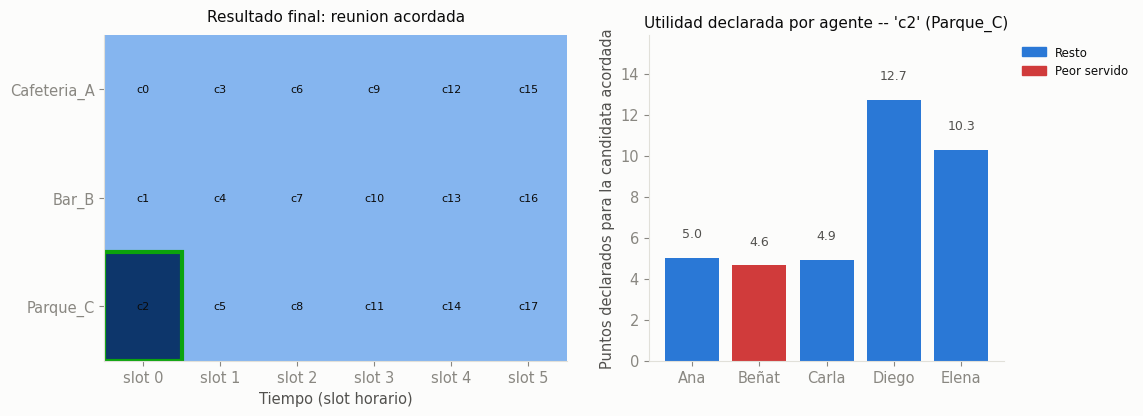

In [71]:
ultimo_msg_puntuar_final = {m.emisor: m for m in bitacora.de_tipo("puntuar") if m.ronda == ronda}
utilidades_declaradas_final = {
    emisor: msg.payload["votos"].get(acordada.id, 0.0)
    for emisor, msg in ultimo_msg_puntuar_final.items()
}
nombres_orden = [a.nombre for a in agentes]
vals_u = [utilidades_declaradas_final.get(n, np.nan) for n in nombres_orden]
peor = min(utilidades_declaradas_final, key=utilidades_declaradas_final.get)
colores_u = [CRITICAL if n == peor else CAT["blue"] for n in nombres_orden]

fig_final, axes_final = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})

mat_final = np.zeros(grid_shape)
for (i, j), cid in candidata_por_celda.items():
    mat_final[i, j] = 1.0 if cid == acordada.id else (0.25 if cid in feasible_ids else 0.02)
_dibujar_calendario(axes_final[0], mat_final, "Resultado final: reunion acordada")
i, j = lugar_index[acordada.l], slot_index[acordada.t]
axes_final[0].add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                            edgecolor=GOOD, linewidth=3))

axes_final[1].bar(nombres_orden, vals_u, color=colores_u)
for k, v in enumerate(vals_u):
    axes_final[1].text(k, v + 1, f"{v:.1f}", ha="center", fontsize=9, color=INK_2)
axes_final[1].set_ylim(0, max(v for v in vals_u if not np.isnan(v)) * 1.25)
axes_final[1].set_ylabel("Puntos declarados para la candidata acordada")
axes_final[1].set_title(f"Utilidad declarada por agente -- '{acordada.id}' ({acordada.l})", fontsize=11)
handles = [mpatches.Patch(color=CAT["blue"], label="Resto"),
           mpatches.Patch(color=CRITICAL, label="Peor servido")]
axes_final[1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=8.5)

fig_final.subplots_adjust(top=0.88, right=0.82, left=0.07, bottom=0.14)
plt.show()